# Coloring mapper graphs based on subgroups

**Author:** Erik Am&eacute;zquita

**Date:** January 2026

This is a short notebook on how to generate Mapper graphs with a variety of parameters. Mapper is one of the many tools available from Topological Data Analysis (TDA). In this case, the analysis is targeted to RNAseq data. Choosing the right parameters is a combination of math, art, and some luck. This is by no means an exhaustive list of things to try, but it (hopefully) will provide a good starting point from which finer analyses can be devised.

## On the usage of this Notebook

You don't need to know how to code to use this notebook. If you've managed to get a open this very notebook with Jupyter, you've already done the hardest part. You will only need to change three numbers and one/two names in Part IV. Look for the sparkle symbols (&#10024;) below that will encourage where to change values.

- You only need to click run for *all* cells.
- You only need to run Parts I thru III *once* (running them again won't do anything bad but will take longer).
- You will need to edit the code for Part IV, and Part IV only: it will be easy, I promise.
- After you edit Part IV, you'll need to run Part V and act on Part VI
- You will repeat Parts IV thru VI to explore the data through Mapper

## Some observations on what to expect

There might be exceptions, but in general you might expect

- Changing `lens` (filter function) will affect the **most** the final color distribution (and possibly shape) of the mapper graph
- As well as choosing between using one or two lens functions at time
- The higher the number of `bins`, the more nodes you'll have in the mapper
- The higher the `overlap` percentage, the more edges you'll have between nodes
- Low `eps` value for clustering can result in a low percentage of unique genes represented in the mapper graph

---

# Part I: Imports

We start importing some standard libraries and sublibraries for non-TDA stuff. For the mapper-specific computations, we'll use `kmapper.`

In [1]:
import os
import glob
import copy
import re
import itertools
from importlib import reload

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import networkx as nx
import utils

import matplotlib as mpl

---

# Part II: Load and transform the reads

- Repeat the transformation as in the Notebook 01

In [2]:
fs = 12
min_tpm = 100
nlabels = ['min', 'mean', 'max', 'median', 'std', 'size', 'sqrtsize', 'cbrtsize']
plot_kw = dict(format='png', bbox_inches='tight', dpi=150)

src = os.pardir + os.sep + 'raw' + os.sep
dst = os.pardir + os.sep + 'outputs' + os.sep
pdst = os.pardir + os.sep + 'plots' + os.sep
cdst = os.pardir + os.sep + 'positions' + os.sep
if not os.path.isdir(cdst):
    os.mkdir(cdst)
if not os.path.isdir(pdst):
    os.mkdir(pdst)
p = re.compile('(.*)_B(.*)_Ov(.*)_dbscan(.*)')

tpm = pd.read_csv(src + 'TPM_combined.csv', index_col=0)
deseq2 = pd.read_csv(src + 'DESeq2_combined.csv', index_col=0)
filters = pd.read_csv(src + 'Combined_gene_filters.csv', index_col=0)
lenses = ['LFC New', 'LFC Attack']

---

# Part III: Load the mapper graph

You've already computed and saved the mapper graphs as HTML files in the Notebook 01. Now we simply load those HTMLs for further analysis.

### &#10024; Change the filename accordingly. Make sure it ends in `.html`

In [155]:
# Replace the filename 
filename = dst + 'TPM_MeanCorr_B70_Ov50_dbscan0,6'
if len(os.path.splitext(filename)[1]) == 0:
    filename += '.html'

# You don't need to change anything else
# Figure out Mapper parameters based on the filename
bname = os.path.splitext(os.path.split(filename)[1])[0]
filternames, binno, overlap, dbscan = p.findall(bname)[0]
filternames = filternames.replace('_',' ').replace('+',' & ')
dbscan = dbscan.replace(',','.')
overlap += '%'
print(filternames, binno, overlap, dbscan, sep='\t')
mtitle = f'Filters: {filternames}, Bins#: {binno}, Overlap: {overlap}, DBSCAN($\\varepsilon$): {dbscan}'
fname = pdst + bname
print(mtitle)

TPM MeanCorr	70	50%	0.6
Filters: TPM MeanCorr, Bins#: 70, Overlap: 50%, DBSCAN($\varepsilon$): 0.6


Now we load the HTML mapper data and make a Networkx graph out of it.
- If Kamada Kawai Layout takes toooo much time, comment it out by adding a `#` in front of all the references

In [156]:
# Load the actual Mapper info
with open(filename, encoding="utf-8") as f:
    jdict = utils.html2json(f.read())
graph = utils.json2mapperG(jdict)

# Compute some basic metrics for each node
columns = list(itertools.chain(*[ [f'{lenses[i]} {ll}' for ll in nlabels[:5] ] for i in range(len(lenses)) ]))+nlabels[5:]
metanode = pd.DataFrame(np.nan, index=graph['nodes'].keys(), columns=columns)
for key in metanode.index:
    metanode.loc[key, 'size'] = len(graph['nodes'][key])
    for ls in lenses:
        nn = filters[ls].iloc[ graph['nodes'][key] ]
        for attr in nlabels[:5]:
            metanode.loc[key, ls + ' ' + attr] = getattr( np, attr)(nn)
metanode['sqrtsize'] = np.sqrt(metanode['size'])
metanode['cbrtsize'] = np.cbrt(metanode['size'])

In [157]:
# Make a networkx G with the mapper data
G = utils.mapper2networkx(graph)
nG = list(G.nodes)
edge_weights = [None] + list(list(G.edges(data=True))[0][-1].keys())[1:]

# Get the largest connected component
# Some layouts only work with a connected component
S = [G.subgraph(c).copy() for c in sorted(nx.connected_components(G), key=len, reverse=True)]
nS = list(S[0].nodes)
lowest = metanode.loc[ nS , lenses[0] + ' median'].idxmin()
furthest = pd.Series(nx.shortest_path_length(S[0], source=lowest, weight='invsize'))[nS].sort_values().index

# Copy G and connect all the components with new edges of weight `zeroweight`
# We'll then remove these temporary edges
zeroweight = 3
temp_edge = []
Gcpy = G.copy()
for ix in range(1, len(S)):
    temp_edge.append( (furthest[-2*ix], list(S[ix].nodes)[0]) )
    Gcpy.add_edge(temp_edge[-1][0], temp_edge[-1][1], size=zeroweight)

In [158]:
# Compute a bunch of layouts
spring = nx.spring_layout(Gcpy, seed=4, weight='size'); print('spring')
spectral = nx.spectral_layout(Gcpy,  weight='size'); print('spectral')
force = nx.forceatlas2_layout(Gcpy, seed=4, weight='size'); print('force')

# Organize the layouts in a dictionary
dpos = {
    'spring': spring,
    'spectral': spectral,
    'force atlas': force,
}
if len(G) < 100:
    kawai = nx.kamada_kawai_layout(Gcpy,  weight='invsize'); print('kawai')
    dpos['kawai'] = kawai

# Arrange all the X,Y node positions in a dataframe
dfpos = pd.DataFrame()
for key in dpos:
    dfpos = pd.concat( (dfpos, pd.DataFrame(dpos[key], index=[key+'_x', key+'_y'] )), axis='index')
dfpos = dfpos.T.loc[nG]

# "Remove" the temporary edges by setting their weight to zero
nx.set_edge_attributes(Gcpy, dict(zip(temp_edge, np.zeros(len(temp_edge)))), 'size')
width = np.array([ foo[2] for foo in  Gcpy.edges(data='size')])
drawkw = dict(G=Gcpy, node_size=0, width = 0.75*np.cbrt(width), 
              edge_color=width, edge_cmap=mpl.colormaps['Greys'], edge_vmin=-7, edge_vmax=7,
              with_labels=False, hide_ticks=True, font_size=6)
dfpos.to_csv(cdst + bname + '.csv', index=True, index_label='node')

spring
spectral
force


Plot the mapper graph based on different layouts
- If you removed the Kamada Kawai layout, replace `kamada kawai` with `random` below.
- Else leave it unchanged

0.6870326657331027
0.169216613918663


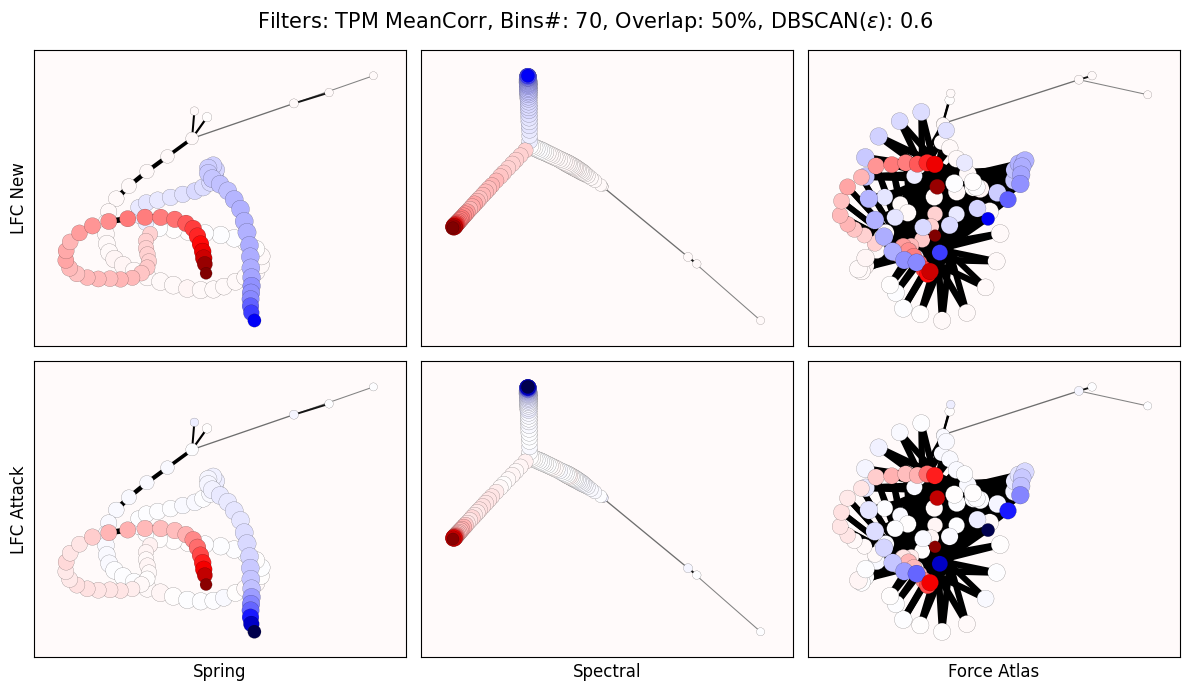

In [160]:
scatterkw = dict(s=20*metanode.loc[nG, 'cbrtsize'], cmap='seismic', ec='k', lw=0.1, zorder=4, alpha=1)
fig, ax = plt.subplots(len(lenses),len(dpos), figsize=(4*len(dpos),3.5*len(lenses))); 

for i,lens in enumerate(lenses):
    c = metanode.loc[nG,  lens + ' median']
    vmax = c.abs().max()
    print(vmax)
    ax[i,0].set_ylabel(lens, fontsize=fs)
    for j,key in enumerate(dpos):    
        nx.draw_networkx(pos=dpos[key], ax=ax[i,j], **drawkw )
        ax[i,j].scatter(dfpos[key+'_x'], dfpos[key+'_y'] , c=c, vmin=-vmax, vmax=vmax, label='LFC', **scatterkw)
        ax[i,j].set_facecolor('snow')
for j,key in enumerate(dpos):
    ax[-1,j].set_xlabel(key.title(), fontsize=fs)
fig.suptitle(mtitle, fontsize=1.25*fs)
fig.tight_layout();
#fig.savefig(fname + '_layout.' + plot_kw['format'], **plot_kw)

### &#10024; Make note of the layout that looks better to you. Make sure it is all lowercase.

In [22]:
poskey = 'kamada kawai'

# No need to edit this line
ffname = fname+'_'+poskey.replace(' ', '_')